# Data Analysis: Enjoyment
This script contains the data analysis for Enjoyment.

### Content:
* Stacked percentage bar chart
* Mean and SD per group
* Omega Coefficient
* Normality check (Shapiro-Wilk & Q-Q plot)
* ANOVA



In [1]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 3.8 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import pingouin as pg
import scipy.stats as stats
import statsmodels.api as sm
import pylab as py

# Load data (csv format)

file_path = "/content/results-filtered-94.csv"
df = pd.read_csv(file_path, sep=";")

print(f"Data shape: {df.shape[0]} rows, {df.shape[1]} columns\n") # Replace with your filename

# Removes the string descriptions in the data
df = df.replace("7 (strongly agree)", "7")
df = df.replace("1 (strongly disagree)", "1")


Data shape: 94 rows, 80 columns



In [4]:
# Transform strings to numeric values
df["PO4E[SQ001]"] = pd.to_numeric(df["PO4E[SQ001]"], errors="coerce")
df["PO4E[SQ003]"] = pd.to_numeric(df["PO4E[SQ003]"], errors="coerce")
df["PO4E[SQ006]"] = pd.to_numeric(df["PO4E[SQ006]"], errors="coerce")
df["PO4E[SQ008]"] = pd.to_numeric(df["PO4E[SQ008]"], errors="coerce")
df["PO4E[SQ011]"] = pd.to_numeric(df["PO4E[SQ011]"], errors="coerce")
df["PO4E[SQ012]"] = pd.to_numeric(df["PO4E[SQ012]"], errors="coerce")
df["PO4E[SQ017]"] = pd.to_numeric(df["PO4E[SQ017]"], errors="coerce")
df["PO4E[SQ018]"] = pd.to_numeric(df["PO4E[SQ018]"], errors="coerce")

In [5]:
# Define dimension items

dimension_items = ["PO4E[SQ001]", "PO4E[SQ003]", "PO4E[SQ006]", "PO4E[SQ008]", "PO4E[SQ011]", "PO4E[SQ012]", "PO4E[SQ017]", "PO4E[SQ018]"]

# Create a subset dataframe containing just these items
df_dim = df[dimension_items].dropna()

Stacked percentage bar chart

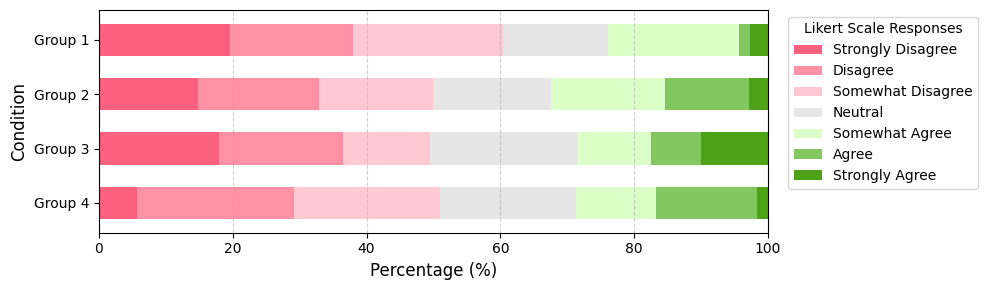

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dimensions = {
    "Enjoyment": dimension_items
}

likert_labels = [
    "Strongly Disagree",
    "Disagree",
    "Somewhat Disagree",
    "Neutral",
    "Somewhat Agree",
    "Agree",
    "Strongly Agree",
]

# Aggregate raw responses into percentages
rows = []

# Loop through each group and dimensions
for group_num in sorted(df["group"].unique()):
    group_data = df[df["group"] == group_num]

    for dim_name, item_list in dimensions.items():
        # Flatten items for this dimension into a single row
        flat_responses = group_data[item_list].values.flatten()

        # Count frequencies of scores 1 through 7
        counts = pd.Series(flat_responses).value_counts()

        # Fill scores with 0 counts
        counts = counts.reindex(range(1, 8), fill_value=0)

        # Convert counts into percentages that sum up to 100%
        percentages = (counts / counts.sum()) * 100

        # Save row data labeled by group
        row_entry = {"Label": f"Group {group_num}"}
        for i, score_name in enumerate(likert_labels):
            row_entry[score_name] = percentages.iloc[i]

        rows.append(row_entry)

# Convert processed list into a plotting DataFrame
df_plot = pd.DataFrame(rows).set_index("Label")


likert_colors = [
    "#fb607f",  # Strongly Disagree (Deep Red)
    "#ff91a4",  # Disagree (Light Red)
    "#ffc9d3",  # Somewhat Disagree (Pink)
    "#e6e6e6",  # Neutral (Light Gray)
    "#daffc7",  # Somewhat Agree (Light Green)
    "#83c760",  # Agree (Medium Green)
    "#4ea217",  # Strongly Agree (Deep Green)
]

fig, ax = plt.subplots(figsize=(10, 3))

# Plot horizontal stacked bar chart
df_plot.plot(
    kind="barh", stacked=True, color=likert_colors, width=0.6, ax=ax
)

# Reverse the vertical axis layout so group 1 appears at the top
ax.invert_yaxis()

ax.set_xlabel("Percentage (%)", fontsize=12)
ax.set_ylabel("Condition", fontsize=12)
ax.set_xlim(0, 100)
ax.xaxis.grid(True, linestyle="--", alpha=0.6)

# Position the legend outside the chart on the right side
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Likert Scale Responses",
    frameon=True,
)

plt.tight_layout()
plt.show()

In [7]:
# Aggregate data (mean & SD)

# Calculate the mean across the rows for x items
# This creates a new column in the original dataframe
df["Dimension_Mean_Score"] = df_dim.mean(axis=1)

# Calculate the mean of the participant means, grouped by the 'group' column
group_means = df.groupby('group')['Dimension_Mean_Score'].mean()
group_sd = df.groupby('group')['Dimension_Mean_Score'].std()

print("--- Enjoyment mean scores per group ---")
print(group_means)

# high sd = values are spread out further from mean
# low sd = data points cluster closer to mean
print("--- Enjoyment SD per group ---")
print(group_sd)

--- Enjoyment mean scores per group ---
group
1    3.130435
2    3.528409
3    3.520000
4    3.609375
Name: Dimension_Mean_Score, dtype: float64
--- Enjoyment SD per group ---
group
1    1.090036
2    1.166836
3    1.237795
4    1.141671
Name: Dimension_Mean_Score, dtype: float64


In [8]:
!Rscript -e "install.packages('psych', repos='https://cloud.r-project.org')"

%load_ext rpy2.ipython

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘mnormt’, ‘GPArotation’

trying URL 'https://cloud.r-project.org/src/contrib/mnormt_2.1.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/GPArotation_2026.6-1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/psych_2.6.5.tar.gz'
* installing *source* package ‘mnormt’ ...
** this is package ‘mnormt’ version ‘2.1.2’
** package ‘mnormt’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C compiler: ‘cc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0’
using Fortran compiler: ‘GNU Fortran (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0’
f77  -fpic  -g -O2 -ffile-prefix-map=/build/r-base-gN72Ro/r-base-4.6.0=. -fstack-protector-strong  -c biv-nt.f -o biv-nt.o
cc -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -ffile-prefix-map=/build/r-base-gN72Ro/r-base-4.6.0=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D

In [10]:
%%R -i df_dim

library(psych)

# Calculate McDonald's Omega
# nfactors=1 because your items belong to a single category/construct
omega_result <- omega(df_dim, nfactors=1, plot=FALSE)

print(omega_result)

Omega 
Call: omegah(m = m, nfactors = nfactors, fm = fm, key = key, flip = flip, 
    digits = digits, title = title, sl = sl, labels = labels, 
    plot = plot, n.obs = n.obs, rotate = rotate, Phi = Phi, option = option, 
    covar = covar)
Alpha:                 0.84 
G.6:                   0.9 
Omega Hierarchical:    0.84 
Omega H asymptotic:    0.98 
Omega Total            0.85 

Schmid Leiman Factor loadings greater than  0.2 
               g  F1*   h2   h2   u2 p2 com
PO4E[SQ001] 0.90      0.80 0.80 0.20  1   1
PO4E[SQ003] 0.88      0.78 0.78 0.22  1   1
PO4E[SQ006] 0.69      0.48 0.48 0.52  1   1
PO4E[SQ008] 0.63      0.39 0.39 0.61  1   1
PO4E[SQ011] 0.77      0.59 0.59 0.41  1   1
PO4E[SQ012] 0.61      0.38 0.38 0.62  1   1
PO4E[SQ017] 0.29           0.08 0.92  1   1
PO4E[SQ018] 0.26           0.07 0.93  1   1

With Sums of squares  of:
  g F1*  h2 
3.6 0.0 2.1 

general/max  1.67   max/min =   1.540092e+16
mean percent general =  1    with sd =  0 and cv of  0 
Explained Com

Loading required namespace: GPArotation
Omega_h for 1 factor is not meaningful, just omega_t
In addition: Warning message:
In schmid(m, nfactors, fm, digits, rotate = rotate, n.obs = n.obs,  :
  Omega_h and Omega_asymptotic are not meaningful with one factor


--- Enjoyment Normality Check (Shapiro-Wilk) ---
                             W      pval  normal
Dimension_Mean_Score  0.985463  0.386036    True

--- Enjoyment Normality Check (Q-Q Plot) ---


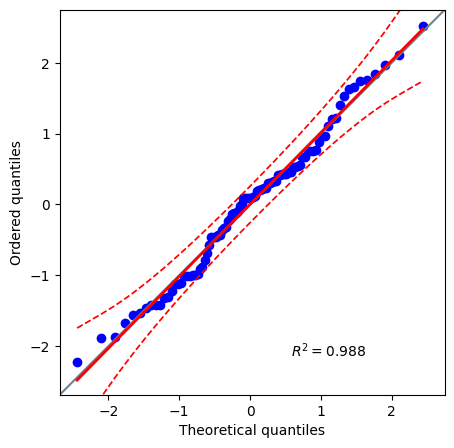

In [13]:
# Normality check
import matplotlib.pyplot as plt
import pingouin as pg

print("--- Enjoyment Normality Check (Shapiro-Wilk) ---")

# Extract the residuals
residuals = df["Dimension_Mean_Score"] - df.groupby(
    'group'
)["Dimension_Mean_Score"].transform("mean")

# Drop any NaN values from the residuals array
clean_residuals = residuals.dropna()

# Shapiro-Wilk Test
# p > 0.05 == data is normally distributed
shapiro_test = pg.normality(clean_residuals)
print(shapiro_test)
print()
print("--- Enjoyment Normality Check (Q-Q Plot) ---")
plt.figure(figsize=(6, 5))
pg.qqplot(clean_residuals, dist="norm")
plt.show()



In [15]:
# Prepare independent variables for two-way ANOVA

language_mapping = {
    1: "Gender-Specific",
    2: "Gender-Neutral",
    3: "Gender-Specific",
    4: "Gender-Neutral"
}

style_mapping = {
    1: "Empathetic",
    2: "Empathetic",
    3: "Neutral",
    4: "Neutral"
}

df['Language'] = df['group'].map(language_mapping)
df['Style'] = df['group'].map(style_mapping)

print("Preview of decoded groups:")
print(df[['group', 'Language', 'Style']].drop_duplicates().to_string(index=False))


Preview of decoded groups:
 group        Language      Style
     3 Gender-Specific    Neutral
     2  Gender-Neutral Empathetic
     1 Gender-Specific Empathetic
     4  Gender-Neutral    Neutral


In [17]:
# Two-way ANOVA

print("--- Levene's Test for Enjoyment ---")

# Categorical independent variables
factor_1 = 'Language'
factor_2 = 'Style'
dependent_var = 'Dimension_Mean_Score'

# Check for Homogeneity of Variances (Levene's Test)
levene_data = df[[dependent_var, 'group']].dropna()

levene_test = pg.homoscedasticity(data=levene_data, dv=dependent_var, group='group')

print(levene_test)

p_value_levene = levene_test['pval'].values[0]
equal_variances = levene_test['equal_var'].values[0]

print(f"Levene's Test p-value: {p_value_levene:.4f}")
print()

print("--- Two-way ANOVA for Enjoyment ---")
# Run the ANOVA (ss_type=3 handles unequal group sizes)
anova_table = pg.anova(data=df, dv=dependent_var, between=[factor_1, factor_2], ss_type=3)

# Display the clean results table
# Check for p_unc < 0.05
print(anova_table[['Source', 'SS', 'DF', 'MS', 'F', 'p_unc', 'np2']].to_string(index=False))
print()

# SS: Sum of Squares - how much data points vary from their average
# DF: Degrees of freedom
# MS: Mean squares - estimate of population variance; used to determine whether factors are significant
# F-statistic: ration of variance between the groups to variance within the groups
# p_unc: uncorrected p-value (if p < 0.05 -> reject null hypothesis)
# Effect size (partial eta-squared; np2): Language explains 24.9% of the total variance in PU
# (np2: 0.01 = small; 0.06 medium; 0.14 large effects)

--- Levene's Test for Enjoyment ---
               W      pval  equal_var
levene  0.038319  0.989912       True
Levene's Test p-value: 0.9899

--- Two-way ANOVA for Enjoyment ---
          Source         SS   DF       MS        F    p_unc      np2
        Language   1.392204  1.0 1.392204 1.031421 0.312548 0.011330
           Style   1.297774  1.0 1.297774 0.961462 0.329447 0.010570
Language * Style   0.558229  1.0 0.558229 0.413566 0.521800 0.004574
        Residual 121.481331 90.0 1.349793      NaN      NaN      NaN

